# GAM Pipeline — Nested Resampling, Full-Data Retuning, and Manifest Export

This notebook compares multiple GAM variants on a shared prepared dataset, selects the winning variant using nested CV, retunes it on all rows, and exports the final manifest-driven artifact set.<br>
**Workflow summary:** resolve raw/log targets, define shared GAM helpers, evaluate each eligible variant with nested resampling, retune the winning variant on full data, then export the selected artifacts and manifest.


## 1. Imports and Configuration
**Purpose:** Load the local helper modules, GAM libraries, and run-scoped configuration that define this comparison run.<br>
**Inputs:** local `src/` package path, prepared-data CSV path, CV/tuning hyperparameters, and export directories.<br>
**Outputs:** imported modelling libraries, resolved paths, and output folders for plots/tables/models.<br>
**How to Verify:** confirm the printed run metadata, `DATA_PATH`, `SAVE_DIR`, and nested-CV settings before any data-dependent logic runs.


In [1]:
# Ensure the notebook can import local helper modules even when it is launched
# from a nested working directory inside the repository.
from pathlib import Path
import sys

for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    src_dir = candidate / 'src'
    if (src_dir / 'data_modelling').exists():
        if str(src_dir) not in sys.path:
            sys.path.insert(0, str(src_dir))
        break
else:
    raise RuntimeError('Could not locate repo src/ directory for notebook imports.')


In [2]:
# Core libraries
import warnings
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold

import optuna
from pygam import LinearGAM, GammaGAM, s

from data_modelling.common_metrics import regression_metrics, rmse, to_original_scale
from data_modelling.prepared_data import load_prepared_data, prepare_dual_target_model_data
from data_modelling.training_outputs import (
    build_oof_frame,
    build_oof_metrics_df,
    build_run_manifest,
    summarize_nested_cv,
    write_manifest,
)

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

MODEL_ID = 'gam'
RUN_NAME = "nusc_mini_debug_tpp-11_Mar_2026_15_29_02"
PREPARED_TARGET_COL = 'ml_ade'
DATA_PATH = Path('../../results/interpretable_model/prepared_data') / RUN_NAME / f'prepared_data_{PREPARED_TARGET_COL}.csv'
TARGET_COL = None  # Optional override, e.g. 'ml_ade_log' or 'ml_ade'

RANDOM_STATE = 42
k_outer_fold = 5
k_inner_fold = 3
N_OPTUNA_TRIALS = 40
POOR_WELL_QUANTILE = 0.20
MIN_SPLINES = 10
MAX_SPLINES = 25
MIN_SPLINE_ORDER = 3
MAX_SPLINE_ORDER = 4
MIN_LAM = 1e-3
MAX_LAM = 1e3
TUNING_METRIC = 'rmse'

SAVE_DIR = Path('../../results/interpretable_model') / MODEL_ID / RUN_NAME
PLOTS_DIR = SAVE_DIR / 'plots'
TABLES_DIR = SAVE_DIR / 'tables'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print('Imports and configuration loaded.')
print(f'Run: {RUN_NAME}')
print(f'Model ID: {MODEL_ID}')
print('Interpretable model: GAM')
print(f'DATA_PATH: {DATA_PATH}')
print(f'SAVE_DIR:  {SAVE_DIR.resolve()}')
print(
    'Nested CV: '
    f'outer={k_outer_fold}, inner={k_inner_fold}, optuna_trials={N_OPTUNA_TRIALS}'
)


Imports and configuration loaded.
Run: nusc_mini_debug_tpp-11_Mar_2026_15_29_02
Model ID: gam
Interpretable model: GAM
DATA_PATH: ../../results/interpretable_model/prepared_data/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/prepared_data_ml_ade.csv
SAVE_DIR:  /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/interpretable_model/gam/nusc_mini_debug_tpp-11_Mar_2026_15_29_02
Nested CV: outer=5, inner=3, optuna_trials=40


## 2. Load Prepared Data and Resolve Targets
**Purpose:** Load the prepared table once and derive a single feature matrix plus both raw/log target views for variant comparison.<br>
**Inputs:** `DATA_PATH`, optional `TARGET_COL` override, and the default target name.<br>
**Outputs:** `model_df`, `X`, `y_raw`, `y_log`, `feature_cols`, and the resolved raw/log target column names.<br>
**How to Verify:** confirm the printed target names, row count, feature count, and array shapes immediately after preparation.


In [3]:
# The preparation helper returns one filtered modelling frame plus both raw/log targets
# so every GAM variant can be compared on exactly the same rows and features.
df = load_prepared_data(DATA_PATH, display_fn=display)

prepared = prepare_dual_target_model_data(
    df,
    target_col=TARGET_COL,
    default_target='ml_ade',
)
raw_target_col = prepared['raw_target_col']
log_target_col = prepared['log_target_col']
target_col = prepared['target_col']
feature_cols = prepared['feature_cols']
model_df = prepared['model_df']
X = prepared['X']
y_raw = prepared['y_raw']
y_log = prepared['y_log']
row_ids = prepared['row_ids']
n_features = prepared['n_features']

print(f'Raw target column: {raw_target_col}')
print(f'Log target column: {log_target_col}')
print(f'Primary target column for nested resampling: {target_col}')
print(f'Number of features: {len(feature_cols)}')
print(f'Rows available for modeling: {len(model_df)}')
print(f'Feature matrix shape: {X.shape}')
print(f'Raw target shape: {y_raw.shape}')
print(f'Log target shape: {y_log.shape}')


Dataset shape: (451, 14)
Columns:
['max_speed', 'std_speed', 'mean_acceleration', 'mean_jerk', 'heading_change', 'has_collision', 'min_neighbor_distance', 'scene_num_agents', 'scene_bbox_area', 'scene_bbox_width', 'scene_bbox_height', 'scene_spatial_density', 'scene_density_VEHICLE', 'ml_ade_log']


,max_speed,std_speed,mean_acceleration,mean_jerk,heading_change,has_collision,min_neighbor_distance,scene_num_agents,scene_bbox_area,scene_bbox_width,scene_bbox_height,scene_spatial_density,scene_density_VEHICLE,ml_ade_log
0,1.230403,0.116722,0.056417,0.490805,112.440745,0.0,1.013903,17.0,1160.377375,40.869190,28.392473,0.014650,0.005171,0.649643
1,0.218477,0.063105,0.007725,0.490449,941.304051,0.0,3.023524,17.0,1160.377375,40.869190,28.392473,0.014650,0.005171,0.140704
2,0.383437,0.099171,0.031384,0.401269,488.173829,0.0,1.104355,50.0,1821.083675,44.533135,40.892780,0.027456,0.012630,0.388765
3,1.483624,0.190256,0.051802,0.879107,81.155053,1.0,0.426945,16.0,1230.401053,43.391608,28.355738,0.013004,0.005689,0.821990
4,0.218477,0.064457,0.010995,0.483671,946.683531,0.0,2.796330,15.0,1057.088774,37.340273,28.309616,0.014190,0.005676,0.159340


Raw target column: ml_ade
Log target column: ml_ade_log
Primary target column for nested resampling: ml_ade_log
Number of features: 13
Rows available for modeling: 451
Feature matrix shape: (451, 13)
Raw target shape: (451,)
Log target shape: (451,)


## 3. Shared Helpers
**Purpose:** Define the reusable building blocks for fitting, tuning, and exporting GAM variants.<br>
**Inputs:** shared feature matrix shape, scaling assumptions, Optuna search ranges, and target-mode metadata.<br>
**Outputs:** helper functions that build GAM terms, fit models, evaluate folds, tune variants, and allocate artifact directories.<br>
**How to Verify:** read each helper in order and confirm that scaling happens before fitting and inverse-scaling happens before metrics are computed.


In [4]:
# These helpers make the shared GAM workflow explicit: build terms, fit one model,
# evaluate a parameter set, tune via inner CV, then allocate per-variant artifact dirs.
def build_gam_terms(n_features, n_splines, spline_order):
    terms = s(0, n_splines=n_splines, spline_order=spline_order)
    for idx in range(1, n_features):
        terms += s(idx, n_splines=n_splines, spline_order=spline_order)
    return terms


def fit_gam_model(model_kind, X_train_scaled, y_train, params):
    terms = build_gam_terms(
        n_features=X_train_scaled.shape[1],
        n_splines=int(params['n_splines']),
        spline_order=int(params['spline_order']),
    )
    if model_kind == 'linear':
        model = LinearGAM(terms, lam=float(params['lam']))
    elif model_kind == 'gamma':
        model = GammaGAM(terms, lam=float(params['lam']))
    else:
        raise ValueError(f'Unsupported model_kind={model_kind}')

    model.fit(X_train_scaled, y_train)
    return model


def evaluate_variant_cv(X_values, y_values, *, model_kind, target_mode, params, seed, variant_name):
    cv = KFold(n_splits=k_inner_fold, shuffle=True, random_state=seed)
    fold_rows = []

    for fold_idx, (train_idx, valid_idx) in enumerate(cv.split(X_values), start=1):
        X_train = X_values[train_idx]
        X_valid = X_values[valid_idx]
        y_train = y_values[train_idx]
        y_valid = y_values[valid_idx]

        # Fit the scaler on the training split only so validation metrics reflect a
        # realistic deployment-time preprocessing pipeline.
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_valid_scaled = scaler.transform(X_valid)

        model = fit_gam_model(model_kind, X_train_scaled, y_train, params)
        y_pred = model.predict(X_valid_scaled)
        y_valid_orig = to_original_scale(y_valid, target_mode=target_mode)
        y_pred_orig = to_original_scale(y_pred, target_mode=target_mode)
        metrics = regression_metrics(y_valid_orig, y_pred_orig)

        fold_rows.append({
            'variant_name': variant_name,
            'fold': fold_idx,
            'R²': metrics['R²'],
            'MAE': metrics['MAE'],
            'RMSE': metrics['RMSE'],
        })

    fold_metrics_df = pd.DataFrame(fold_rows)
    summary = {
        'cv_r2_mean': float(fold_metrics_df['R²'].mean()),
        'cv_r2_std': float(fold_metrics_df['R²'].std(ddof=1)),
        'cv_mae_mean': float(fold_metrics_df['MAE'].mean()),
        'cv_mae_std': float(fold_metrics_df['MAE'].std(ddof=1)),
        'cv_rmse_mean': float(fold_metrics_df['RMSE'].mean()),
        'cv_rmse_std': float(fold_metrics_df['RMSE'].std(ddof=1)),
    }

    return {
        'fold_metrics_df': fold_metrics_df,
        'summary': summary,
    }


def run_gam_optuna_tuning(X_values, y_values, *, model_kind, target_mode, seed, tuning_scope, variant_name):
    trial_rows = []

    def objective(trial):
        params = {
            'n_splines': trial.suggest_int('n_splines', MIN_SPLINES, MAX_SPLINES),
            'spline_order': trial.suggest_int('spline_order', MIN_SPLINE_ORDER, MAX_SPLINE_ORDER),
            'lam': trial.suggest_float('lam', MIN_LAM, MAX_LAM, log=True),
        }

        inner_cv = KFold(n_splits=k_inner_fold, shuffle=True, random_state=seed)
        fold_rmses = []

        for inner_train_idx, inner_valid_idx in inner_cv.split(X_values):
            X_inner_train = X_values[inner_train_idx]
            X_inner_valid = X_values[inner_valid_idx]
            y_inner_train = y_values[inner_train_idx]
            y_inner_valid = y_values[inner_valid_idx]

            scaler = StandardScaler()
            X_inner_train_scaled = scaler.fit_transform(X_inner_train)
            X_inner_valid_scaled = scaler.transform(X_inner_valid)

            try:
                model = fit_gam_model(model_kind, X_inner_train_scaled, y_inner_train, params)
                y_inner_pred = model.predict(X_inner_valid_scaled)
                # Convert back to the raw target scale before ranking trials so raw- and
                # log-target variants compete on the same interpretable error metric.
                y_inner_valid_orig = to_original_scale(y_inner_valid, target_mode=target_mode)
                y_inner_pred_orig = to_original_scale(y_inner_pred, target_mode=target_mode)
                fold_rmses.append(rmse(y_inner_valid_orig, y_inner_pred_orig))
            except Exception:
                # Invalid parameter combinations should lose the trial rather than abort the
                # whole search, so assign an infinite CV RMSE and continue.
                fold_rmses.append(float('inf'))

        mean_cv_rmse = float(np.mean(fold_rmses))
        row = {
            'variant_name': variant_name,
            'tuning_scope': tuning_scope,
            'trial_number': trial.number,
            'mean_cv_rmse': mean_cv_rmse,
            'n_splines': int(params['n_splines']),
            'spline_order': int(params['spline_order']),
            'lam': float(params['lam']),
        }
        trial_rows.append(row)
        return mean_cv_rmse

    study = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=seed),
    )
    study.optimize(objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=False)

    trial_results_df = pd.DataFrame(trial_rows).sort_values('mean_cv_rmse').reset_index(drop=True)
    best_params = {
        'n_splines': int(study.best_params['n_splines']),
        'spline_order': int(study.best_params['spline_order']),
        'lam': float(study.best_params['lam']),
    }
    best_cv_rmse = float(study.best_value)

    print(
        f'{variant_name} | {tuning_scope} tuning complete | '
        f'best_cv_rmse={best_cv_rmse:.6f}'
    )

    return {
        'best_params': best_params,
        'best_cv_rmse': best_cv_rmse,
        'trial_results_df': trial_results_df,
    }


def get_artifact_dirs(model_id):
    save_dir = Path('../../results/interpretable_model') / model_id / RUN_NAME
    plots_dir = save_dir / 'plots'
    tables_dir = save_dir / 'tables'
    plots_dir.mkdir(parents=True, exist_ok=True)
    tables_dir.mkdir(parents=True, exist_ok=True)
    return {
        'save_dir': save_dir,
        'plots_dir': plots_dir,
        'tables_dir': tables_dir,
    }


## 4. Nested Resampling Across GAM Variants
**Purpose:** Evaluate each eligible GAM variant on identical rows/features, store OOF diagnostics, and select the winner using mean outer-fold RMSE.<br>
**Inputs:** `X`, `y_raw`, `y_log`, variant specs, nested-CV settings, and the shared export helpers.<br>
**Outputs:** per-variant nested-CV tables, OOF diagnostics, per-variant manifests, and a comparison table/plot across completed variants.<br>
**How to Verify:** each completed variant should finish without NaN OOF predictions, produce one nested-CV row per outer fold, and appear in the comparison table sorted by `outer_rmse_mean`.


LinearGAM (log) | outer_fold_1 tuning complete | best_cv_rmse=0.375361
LinearGAM (log) | outer fold 1/5 | RMSE=0.364767 | MAE=0.264136 | R2=0.5745
LinearGAM (log) | outer_fold_2 tuning complete | best_cv_rmse=0.394127
LinearGAM (log) | outer fold 2/5 | RMSE=0.428626 | MAE=0.303519 | R2=0.4744
LinearGAM (log) | outer_fold_3 tuning complete | best_cv_rmse=0.418281
LinearGAM (log) | outer fold 3/5 | RMSE=0.398523 | MAE=0.289835 | R2=0.5711
LinearGAM (log) | outer_fold_4 tuning complete | best_cv_rmse=0.404070
LinearGAM (log) | outer fold 4/5 | RMSE=0.386362 | MAE=0.308966 | R2=0.4041
LinearGAM (log) | outer_fold_5 tuning complete | best_cv_rmse=0.412111
LinearGAM (log) | outer fold 5/5 | RMSE=0.405656 | MAE=0.280869 | R2=0.5869
LinearGAM (log) nested CV saved to: ../../results/interpretable_model/gam-linear-log/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/tables/nested_cv_optuna_ml_ade_log.csv
LinearGAM (log) OOF metrics saved to: ../../results/interpretable_model/gam-linear-log/nusc_mini_deb

,variant_model_id,variant_name,outer_rmse_mean,outer_rmse_std,outer_mae_mean,outer_mae_std,outer_r2_mean,outer_r2_std
0,gam-linear-log,LinearGAM (log),0.396787,0.023608,0.289465,0.017982,0.522198,0.079904
1,gam-linear,LinearGAM (no log),0.400396,0.028451,0.300277,0.028842,0.512053,0.096885
2,gam-gamma,GammaGAM,0.402231,0.028021,0.293032,0.026941,0.507658,0.096826


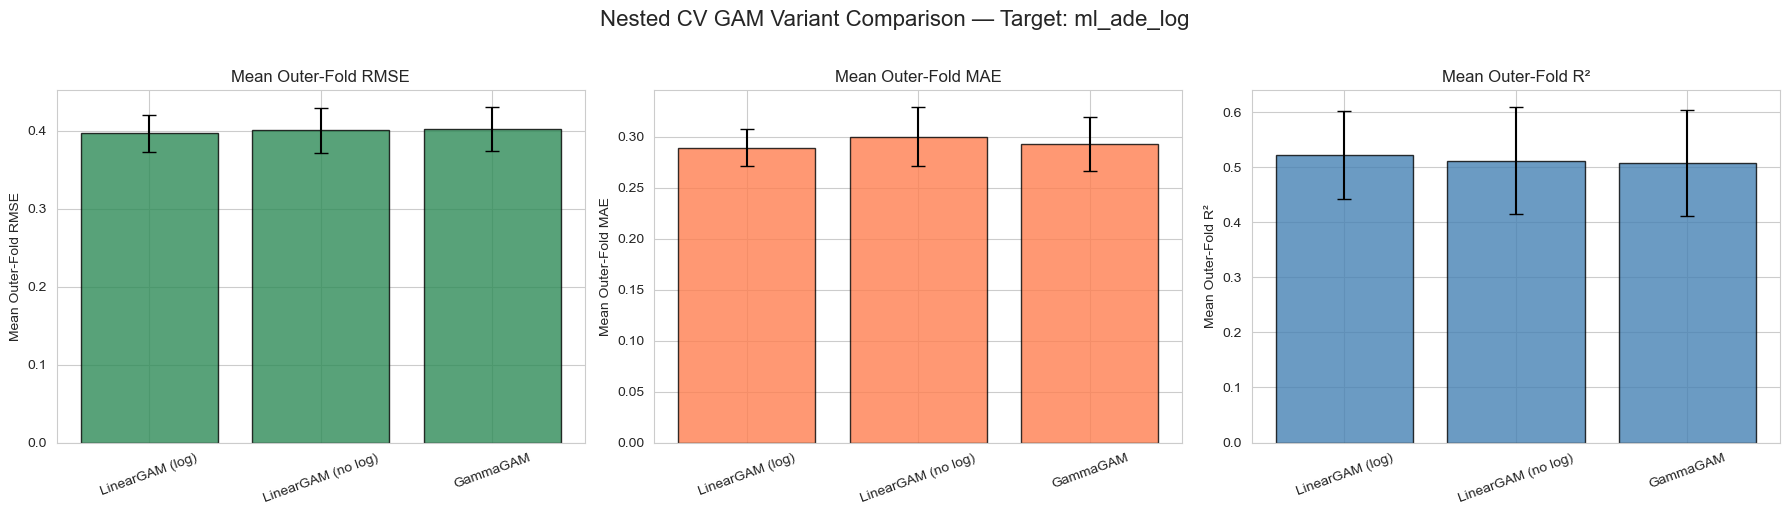

Nested variant comparison table saved to: ../../results/interpretable_model/gam/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/tables/nested_variant_comparison_ml_ade_log.csv
Nested variant comparison plot saved to:  ../../results/interpretable_model/gam/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/plots/nested_variant_comparison_ml_ade_log.png


In [5]:
# Each spec describes one candidate exportable GAM. All variants share the same rows
# and features; only model family and target mode are allowed to differ here.
variant_specs = [
    {
        'variant_model_id': 'gam-linear-log',
        'variant_name': 'LinearGAM (log)',
        'model_kind': 'linear',
        'target_mode': 'log',
        'y_values': y_log,
        'eligible': True,
        'skip_reason': None,
    },
    {
        'variant_model_id': 'gam-linear',
        'variant_name': 'LinearGAM (no log)',
        'model_kind': 'linear',
        'target_mode': 'raw',
        'y_values': y_raw,
        'eligible': True,
        'skip_reason': None,
    },
    {
        'variant_model_id': 'gam-gamma',
        'variant_name': 'GammaGAM',
        'model_kind': 'gamma',
        'target_mode': 'raw',
        'y_values': y_raw,
        'eligible': bool((y_raw > 0).all()),
        'skip_reason': None if (y_raw > 0).all() else 'raw target contains non-positive values',
    },
]

variant_results = []
n_samples = len(model_df)

# Run nested CV independently for each eligible variant and keep variant-specific
# artifacts separate until the comparison step chooses the winner.
for variant_idx, spec in enumerate(variant_specs, start=1):
    if not spec['eligible']:
        variant_results.append({
            'variant_model_id': spec['variant_model_id'],
            'variant_name': spec['variant_name'],
            'model_kind': spec['model_kind'],
            'target_mode': spec['target_mode'],
            'status': 'skipped',
            'skip_reason': spec['skip_reason'],
        })
        print(f"Skipping {spec['variant_name']}: {spec['skip_reason']}")
        continue

    artifact_dirs = get_artifact_dirs(spec['variant_model_id'])
    outer_cv = KFold(n_splits=k_outer_fold, shuffle=True, random_state=RANDOM_STATE)
    oof_pred = np.full(n_samples, np.nan, dtype=float)
    oof_fold = np.full(n_samples, -1, dtype=int)
    nested_rows = []

    for fold_idx, (outer_train_idx, outer_valid_idx) in enumerate(outer_cv.split(X, spec['y_values']), start=1):
        X_outer_train = X[outer_train_idx]
        X_outer_valid = X[outer_valid_idx]
        y_outer_train = spec['y_values'][outer_train_idx]
        y_outer_valid_raw = y_raw[outer_valid_idx]

        tuning_result = run_gam_optuna_tuning(
            X_outer_train,
            y_outer_train,
            model_kind=spec['model_kind'],
            target_mode=spec['target_mode'],
            seed=RANDOM_STATE + variant_idx * 100 + fold_idx,
            tuning_scope=f'outer_fold_{fold_idx}',
            variant_name=spec['variant_name'],
        )

        scaler = StandardScaler()
        X_outer_train_scaled = scaler.fit_transform(X_outer_train)
        X_outer_valid_scaled = scaler.transform(X_outer_valid)
        outer_model = fit_gam_model(
            spec['model_kind'],
            X_outer_train_scaled,
            y_outer_train,
            tuning_result['best_params'],
        )

        outer_pred = outer_model.predict(X_outer_valid_scaled)
        oof_pred[outer_valid_idx] = outer_pred
        oof_fold[outer_valid_idx] = fold_idx

        # Convert predictions back to the raw metric scale before computing the outer
        # fold score used to compare variants.
        outer_pred_orig = to_original_scale(outer_pred, target_mode=spec['target_mode'])
        outer_metrics = regression_metrics(y_outer_valid_raw, outer_pred_orig)

        row = {
            'variant_model_id': spec['variant_model_id'],
            'variant_name': spec['variant_name'],
            'outer_fold': fold_idx,
            'outer_rmse': outer_metrics['RMSE'],
            'outer_mae': outer_metrics['MAE'],
            'outer_r2': outer_metrics['R²'],
            'inner_best_cv_rmse': tuning_result['best_cv_rmse'],
        }
        row.update({f'best_{k}': v for k, v in tuning_result['best_params'].items()})
        nested_rows.append(row)

        print(
            f"{spec['variant_name']} | outer fold {fold_idx}/{k_outer_fold} | "
            f"RMSE={outer_metrics['RMSE']:.6f} | MAE={outer_metrics['MAE']:.6f} | R2={outer_metrics['R²']:.4f}"
        )

    if np.isnan(oof_pred).any():
        raise ValueError(f"OOF predictions contain NaN values for {spec['variant_name']}. Check CV splits and training flow.")

    nested_cv_df = pd.DataFrame(nested_rows)
    nested_summary = summarize_nested_cv(nested_cv_df)
    summary_lookup = nested_summary.set_index('metric')
    selection_metric_value = float(summary_lookup.loc['outer_rmse', 'mean'])

    model_df_oof = build_oof_frame(
        model_df,
        row_ids=row_ids,
        oof_pred=oof_pred,
        oof_fold=oof_fold,
        target_orig=model_df[raw_target_col].to_numpy(),
        pred_scale_kwargs={'target_mode': spec['target_mode']},
    )
    oof_predictions_df = model_df_oof[['row_id', 'oof_pred', 'oof_pred_orig', 'target_orig', 'outer_fold']]
    metrics_df = build_oof_metrics_df(spec['y_values'], oof_pred, target_mode=spec['target_mode'])

    nested_path = artifact_dirs['tables_dir'] / f'nested_cv_optuna_{target_col}.csv'
    nested_summary_path = artifact_dirs['tables_dir'] / f'nested_cv_optuna_summary_{target_col}.csv'
    oof_path = artifact_dirs['tables_dir'] / f'oof_predictions_{target_col}.csv'
    metrics_path = artifact_dirs['tables_dir'] / f'metrics_oof_{target_col}.csv'
    model_data_path = artifact_dirs['tables_dir'] / f'model_data_with_oof_{target_col}.csv'

    nested_cv_df.to_csv(nested_path, index=False)
    nested_summary.to_csv(nested_summary_path, index=False)
    oof_predictions_df.to_csv(oof_path, index=False)
    metrics_df.to_csv(metrics_path, index=False)
    model_df_oof.to_csv(model_data_path, index=False)

    variant_manifest = build_run_manifest(
        model_id=spec['variant_model_id'],
        run_name=RUN_NAME,
        target_col=target_col,
        feature_cols=feature_cols,
        save_dir=artifact_dirs['save_dir'],
        plots_dir=artifact_dirs['plots_dir'],
        tables_dir=artifact_dirs['tables_dir'],
        nested_resampling={
            'nested_cv_path': str(nested_path),
            'nested_cv_summary_path': str(nested_summary_path),
            'oof_predictions_path': str(oof_path),
            'oof_metrics_path': str(metrics_path),
            'model_data_with_oof_path': str(model_data_path),
        },
        final_model={},
        analysis={
            'poor_well_quantile': POOR_WELL_QUANTILE,
        },
        extra_manifest_fields={
            'raw_target_col': raw_target_col,
            'log_target_col': log_target_col,
            'variant_model_id': spec['variant_model_id'],
            'variant_name': spec['variant_name'],
            'model_kind': spec['model_kind'],
            'target_mode': spec['target_mode'],
            'variant_status': 'completed',
            'selection_metric_name': 'mean_outer_rmse',
            'selection_metric_value': selection_metric_value,
        },
    )
    manifest_path = write_manifest(variant_manifest, artifact_dirs['tables_dir'], target_col)

    print(f"{spec['variant_name']} nested CV saved to: {nested_path}")
    print(f"{spec['variant_name']} OOF metrics saved to: {metrics_path}")
    print(f"{spec['variant_name']} manifest saved to:    {manifest_path}")

    variant_results.append({
        'variant_model_id': spec['variant_model_id'],
        'variant_name': spec['variant_name'],
        'model_kind': spec['model_kind'],
        'target_mode': spec['target_mode'],
        'status': 'completed',
        'selection_metric_name': 'mean_outer_rmse',
        'selection_metric_value': selection_metric_value,
        'outer_r2_mean': float(summary_lookup.loc['outer_r2', 'mean']),
        'outer_r2_std': float(summary_lookup.loc['outer_r2', 'std']),
        'outer_mae_mean': float(summary_lookup.loc['outer_mae', 'mean']),
        'outer_mae_std': float(summary_lookup.loc['outer_mae', 'std']),
        'outer_rmse_mean': float(summary_lookup.loc['outer_rmse', 'mean']),
        'outer_rmse_std': float(summary_lookup.loc['outer_rmse', 'std']),
        'nested_cv_path': str(nested_path),
        'nested_cv_summary_path': str(nested_summary_path),
        'oof_predictions_path': str(oof_path),
        'oof_metrics_path': str(metrics_path),
        'model_data_with_oof_path': str(model_data_path),
        'manifest_path': str(manifest_path),
    })

completed_variants = [row for row in variant_results if row['status'] == 'completed']
if not completed_variants:
    raise ValueError('No eligible GAM variants completed nested CV.')

# Lowest mean outer-fold RMSE on the original scale is the single selection rule that
# determines which GAM variant graduates to the full-data refit.
selected_variant = min(completed_variants, key=lambda row: row['outer_rmse_mean'])
print('Selected GAM variant based on lowest mean outer-fold RMSE on original scale:')
print(selected_variant)

variant_comparison_df = pd.DataFrame(completed_variants)[[
    'variant_model_id',
    'variant_name',
    'outer_rmse_mean',
    'outer_rmse_std',
    'outer_mae_mean',
    'outer_mae_std',
    'outer_r2_mean',
    'outer_r2_std',
]].sort_values('outer_rmse_mean').reset_index(drop=True)
display(variant_comparison_df)

variant_comparison_path = TABLES_DIR / f'nested_variant_comparison_{target_col}.csv'
variant_comparison_df.to_csv(variant_comparison_path, index=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metric_specs = [
    ('outer_rmse_mean', 'outer_rmse_std', 'Mean Outer-Fold RMSE', 'seagreen'),
    ('outer_mae_mean', 'outer_mae_std', 'Mean Outer-Fold MAE', 'coral'),
    ('outer_r2_mean', 'outer_r2_std', 'Mean Outer-Fold R²', 'steelblue'),
]
for ax, (mean_col, std_col, title, color) in zip(axes, metric_specs):
    ax.bar(
        variant_comparison_df['variant_name'],
        variant_comparison_df[mean_col],
        yerr=variant_comparison_df[std_col],
        color=color,
        edgecolor='black',
        alpha=0.8,
        capsize=5,
    )
    ax.set_title(title)
    ax.set_ylabel(title)
    ax.tick_params(axis='x', rotation=20)

plt.suptitle(f'Nested CV GAM Variant Comparison — Target: {target_col}', fontsize=16, y=1.02)
plt.tight_layout()
variant_comparison_plot_path = PLOTS_DIR / f'nested_variant_comparison_{target_col}.png'
plt.savefig(variant_comparison_plot_path, dpi=150, bbox_inches='tight')
plt.show()

print(f'Nested variant comparison table saved to: {variant_comparison_path}')
print(f'Nested variant comparison plot saved to:  {variant_comparison_plot_path}')


## 5. Full-Data Retuning for the Winning GAM Variant
**Purpose:** Reuse the winning variant definition on all filtered rows to obtain the exportable final GAM and its tuning summary.<br>
**Inputs:** selected nested-CV winner, full filtered feature matrix, matching target mode, and the same Optuna search space.<br>
**Outputs:** full-data tuning trials, tuning summary JSON, fitted scaler, and fitted final GAM model.<br>
**How to Verify:** confirm the printed winner matches the lowest `outer_rmse_mean`, then confirm the saved tuning summary records the same selected variant metadata and best CV RMSE.


In [6]:
# Refit only the winning target mode/model family on all filtered rows. This keeps
# the exported GAM aligned with the same selection rule used during nested CV.
selected_variant_y = y_log if selected_variant['target_mode'] == 'log' else y_raw

full_data_tuning = run_gam_optuna_tuning(
    X,
    selected_variant_y,
    model_kind=selected_variant['model_kind'],
    target_mode=selected_variant['target_mode'],
    seed=RANDOM_STATE + 1000,
    tuning_scope='full_data',
    variant_name=selected_variant['variant_name'],
)
full_data_tuning_trials_df = full_data_tuning['trial_results_df']
full_data_tuning_trials_path = TABLES_DIR / f'full_data_tuning_optuna_trials_{target_col}.csv'
full_data_tuning_trials_df.to_csv(full_data_tuning_trials_path, index=False)

selected_variant_nested_summary = {
    'outer_rmse_mean': selected_variant['outer_rmse_mean'],
    'outer_rmse_std': selected_variant['outer_rmse_std'],
    'outer_mae_mean': selected_variant['outer_mae_mean'],
    'outer_mae_std': selected_variant['outer_mae_std'],
    'outer_r2_mean': selected_variant['outer_r2_mean'],
    'outer_r2_std': selected_variant['outer_r2_std'],
}

full_data_tuning_summary = {
    'model_id': MODEL_ID,
    'run_name': RUN_NAME,
    'target_col': target_col,
    'raw_target_col': raw_target_col,
    'log_target_col': log_target_col,
    'selection_metric_name': 'mean_outer_rmse',
    'selection_metric_value': selected_variant['selection_metric_value'],
    'variant_results': variant_results,
    'nested_variant_comparison_path': str(variant_comparison_path),
    'nested_variant_comparison_plot_path': str(variant_comparison_plot_path),
    'selected_variant_model_id': selected_variant['variant_model_id'],
    'selected_variant_manifest_path': selected_variant['manifest_path'],
    'selected_variant_name': selected_variant['variant_name'],
    'selected_variant_model_kind': selected_variant['model_kind'],
    'selected_variant_target_mode': selected_variant['target_mode'],
    'selected_variant_nested_summary': selected_variant_nested_summary,
    'selected_best_params': full_data_tuning['best_params'],
    'full_data_best_cv_rmse': full_data_tuning['best_cv_rmse'],
    'tuning_config': {
        'nfold': k_inner_fold,
        'n_trials': N_OPTUNA_TRIALS,
        'n_splines_range': [MIN_SPLINES, MAX_SPLINES],
        'spline_order_range': [MIN_SPLINE_ORDER, MAX_SPLINE_ORDER],
        'lam_range': [MIN_LAM, MAX_LAM],
        'random_state': RANDOM_STATE,
    },
}
full_data_tuning_summary_path = TABLES_DIR / f'full_data_tuning_optuna_summary_{target_col}.json'
full_data_tuning_summary_path.write_text(json.dumps(full_data_tuning_summary, indent=2))

selected_y = selected_variant_y
# Fit one final scaler on all selected rows because the exported GAM expects scaled
# inputs identical to the data used during the full-data refit.
final_scaler = StandardScaler()
X_scaled_all = final_scaler.fit_transform(X)
final_model = fit_gam_model(
    selected_variant['model_kind'],
    X_scaled_all,
    selected_y,
    full_data_tuning['best_params'],
)

print(
    'Selected GAM variant based on lowest mean outer-fold RMSE on original scale: '
    f"{selected_variant['variant_name']} ({selected_variant['variant_model_id']})"
)
print(f"- mean_outer_rmse={selected_variant['selection_metric_value']:.6f}")
print(f"- full_data_best_cv_rmse={full_data_tuning['best_cv_rmse']:.6f}")
print(f'Full-data tuning trials saved to: {full_data_tuning_trials_path}')
print(f'Full-data tuning summary saved to: {full_data_tuning_summary_path}')
print('Final GAM model fitted on all data using the selected full-data-retuned variant.')


LinearGAM (log) | full_data tuning complete | best_cv_rmse=0.386991
Selected GAM variant based on lowest mean outer-fold RMSE on original scale: LinearGAM (log) (gam-linear-log)
- mean_outer_rmse=0.396787
- full_data_best_cv_rmse=0.386991
Full-data tuning trials saved to: ../../results/interpretable_model/gam/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/tables/full_data_tuning_optuna_trials_ml_ade_log.csv
Full-data tuning summary saved to: ../../results/interpretable_model/gam/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/tables/full_data_tuning_optuna_summary_ml_ade_log.json
Final GAM model fitted on all data using the selected full-data-retuned variant.


## 6. Export Artifacts and Run Manifest
**Purpose:** Persist the final selected GAM, copy the winning nested-CV diagnostics into the canonical GAM run directory, and publish a manifest for downstream analysis.<br>
**Inputs:** final fitted GAM/scaler, winning variant artifact paths, full-data tuning outputs, and run metadata.<br>
**Outputs:** saved model/scaler pickles, canonical nested-CV and OOF tables, and `run_manifest_<target>.json` for the selected GAM run.<br>
**How to Verify:** confirm the copied canonical tables match the winning variant paths, and confirm the final manifest points to the copied canonical files rather than the variant-specific originals.


In [7]:
# Copy the winning variant's diagnostics into the canonical GAM directory so downstream
# notebooks can load one stable manifest regardless of which variant won internally.
model_path = SAVE_DIR / f'gam_model_{target_col}.pkl'
with model_path.open('wb') as f:
    pickle.dump(final_model, f)

scaler_path = SAVE_DIR / f'gam_scaler_{target_col}.pkl'
with scaler_path.open('wb') as f:
    pickle.dump(final_scaler, f)

selected_nested_cv_path = TABLES_DIR / f'nested_cv_optuna_{target_col}.csv'
selected_nested_summary_path = TABLES_DIR / f'nested_cv_optuna_summary_{target_col}.csv'
selected_oof_path = TABLES_DIR / f'oof_predictions_{target_col}.csv'
selected_metrics_path = TABLES_DIR / f'metrics_oof_{target_col}.csv'
data_path = TABLES_DIR / f'model_data_with_oof_{target_col}.csv'

pd.read_csv(selected_variant['nested_cv_path']).to_csv(selected_nested_cv_path, index=False)
pd.read_csv(selected_variant['nested_cv_summary_path']).to_csv(selected_nested_summary_path, index=False)
pd.read_csv(selected_variant['oof_predictions_path']).to_csv(selected_oof_path, index=False)
pd.read_csv(selected_variant['oof_metrics_path']).to_csv(selected_metrics_path, index=False)
pd.read_csv(selected_variant['model_data_with_oof_path']).to_csv(data_path, index=False)

# The manifest intentionally references the canonical copied files, not the variant
# scratch directory, because analysis notebooks load only this top-level GAM run.
manifest = build_run_manifest(
    model_id=MODEL_ID,
    run_name=RUN_NAME,
    target_col=target_col,
    feature_cols=feature_cols,
    save_dir=SAVE_DIR,
    plots_dir=PLOTS_DIR,
    tables_dir=TABLES_DIR,
    nested_resampling={
        'nested_cv_path': str(selected_nested_cv_path),
        'nested_cv_summary_path': str(selected_nested_summary_path),
        'oof_predictions_path': str(selected_oof_path),
        'oof_metrics_path': str(selected_metrics_path),
        'model_data_with_oof_path': str(data_path),
    },
    final_model={
        'model_path': str(model_path),
        'scaler_path': str(scaler_path),
        'full_data_tuning_trials_path': str(full_data_tuning_trials_path),
        'full_data_tuning_summary_path': str(full_data_tuning_summary_path),
        'nested_variant_comparison_path': str(variant_comparison_path),
        'nested_variant_comparison_plot_path': str(variant_comparison_plot_path),
        'selected_variant_model_id': selected_variant['variant_model_id'],
        'selected_variant_manifest_path': selected_variant['manifest_path'],
        'selected_variant_name': selected_variant['variant_name'],
        'selected_variant_model_kind': selected_variant['model_kind'],
        'selected_variant_target_mode': selected_variant['target_mode'],
        'selected_variant_nested_summary': selected_variant_nested_summary,
        'selected_best_params': full_data_tuning['best_params'],
        'selected_full_data_best_cv_rmse': full_data_tuning['best_cv_rmse'],
        'exported_model_name': selected_variant['variant_name'],
        'exported_model_kind': selected_variant['model_kind'],
        'exported_model_target_mode': selected_variant['target_mode'],
        'exported_model_selection_metric_name': 'mean_outer_rmse',
        'exported_model_selection_metric_value': selected_variant['selection_metric_value'],
    },
    analysis={
        'poor_well_quantile': POOR_WELL_QUANTILE,
    },
    extra_manifest_fields={
        'raw_target_col': raw_target_col,
        'log_target_col': log_target_col,
        'winning_variant_model_id': selected_variant['variant_model_id'],
        'winning_variant_name': selected_variant['variant_name'],
        'winning_variant_model_kind': selected_variant['model_kind'],
        'winning_variant_target_mode': selected_variant['target_mode'],
        'selection_metric_name': 'mean_outer_rmse',
        'selection_metric_value': selected_variant['selection_metric_value'],
    },
)
manifest_path = write_manifest(manifest, TABLES_DIR, target_col)

print(f'Final GAM model saved to: {model_path}')
print(f'Final GAM scaler saved to: {scaler_path}')
print(f'Selected nested CV fold results copied to: {selected_nested_cv_path}')
print(f'Selected OOF metrics copied to:            {selected_metrics_path}')
print(f'Model data with OOF predictions saved to: {data_path}')
print(f'Run manifest saved to: {manifest_path}')
print('Exported model summary:')
print(f"- Name: {selected_variant['variant_name']}")
print(f"- Kind: {selected_variant['model_kind']}")
print(f"- Target mode: {selected_variant['target_mode']}")
print(f"- Selection metric: mean_outer_rmse={selected_variant['selection_metric_value']:.6f}")
print(f"- Full-data best_cv_rmse: {full_data_tuning['best_cv_rmse']:.6f}")


Final GAM model saved to: ../../results/interpretable_model/gam/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/gam_model_ml_ade_log.pkl
Final GAM scaler saved to: ../../results/interpretable_model/gam/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/gam_scaler_ml_ade_log.pkl
Selected nested CV fold results copied to: ../../results/interpretable_model/gam/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/tables/nested_cv_optuna_ml_ade_log.csv
Selected OOF metrics copied to:            ../../results/interpretable_model/gam/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/tables/metrics_oof_ml_ade_log.csv
Model data with OOF predictions saved to: ../../results/interpretable_model/gam/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/tables/model_data_with_oof_ml_ade_log.csv
Run manifest saved to: ../../results/interpretable_model/gam/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/tables/run_manifest_ml_ade_log.json
Exported model summary:
- Name: LinearGAM (log)
- Kind: linear
- Target mode: log
- Selection metric: mean_outer_rmse=0.